<a href="https://colab.research.google.com/github/mdzubayereashraf/Ostad-AI-Engineering-Course-Assignments/blob/main/Assignmen_No_14(Deep_Learning_Project_Dog_vs_Cat_Image_Classification).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Module 14 Project: Dog vs Cat Image Classification**

## **Objective:**

The goal of this project is to build and evaluate deep learning models
for binary image classification of dogs and cats.

Three different approaches will be compared:

1. Custom CNN
2. Transfer Learning using MobileNetV2 (Feature Extraction)
3. Transfer Learning using EfficientNetB0 (Full Fine-Tuning)

The models will be evaluated using accuracy, precision, recall, F1-score,
loss, confusion matrix, and error analysis.

# **Question 1 : Dataset Preparation**

### **Download The Dataset**

In [2]:
!git clone https://github.com/laxmimerit/dog-cat-full-dataset.git

Cloning into 'dog-cat-full-dataset'...
remote: Enumerating objects: 25059, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 25059 (delta 4), reused 6 (delta 2), pack-reused 25048 (from 1)
Receiving objects: 100% (25059/25059), 541.54 MiB | 20.03 MiB/s, done.
Resolving deltas: 100% (21/21), done.
Updating files: 100% (24990/24990), done.


### **Import all required libraries**

In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)


### **Load the datasets**

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dir = "/content/dog-cat-full-dataset/data/train"
test_dir = "/content/dog-cat-full-dataset/data/test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

print("Class names:", class_names)

Found 19989 files belonging to 2 classes.
Using 15992 files for training.
Found 19989 files belonging to 2 classes.
Using 3997 files for validation.
Found 5000 files belonging to 2 classes.
Class names: ['cats', 'dogs']


### **Number of samples**

In [5]:
train_samples = len(train_ds.file_paths)
val_samples = len(val_ds.file_paths)
test_samples = len(test_ds.file_paths)

print("Training samples:", train_samples)
print("Validation samples:", val_samples)
print("Test samples:", test_samples)

Training samples: 15992
Validation samples: 3997
Test samples: 5000


### **Normalize**

In [6]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

### **Prefetch**

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# **Question 2 : Data Augmentation**

In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

### **Original + 4 augmented images**

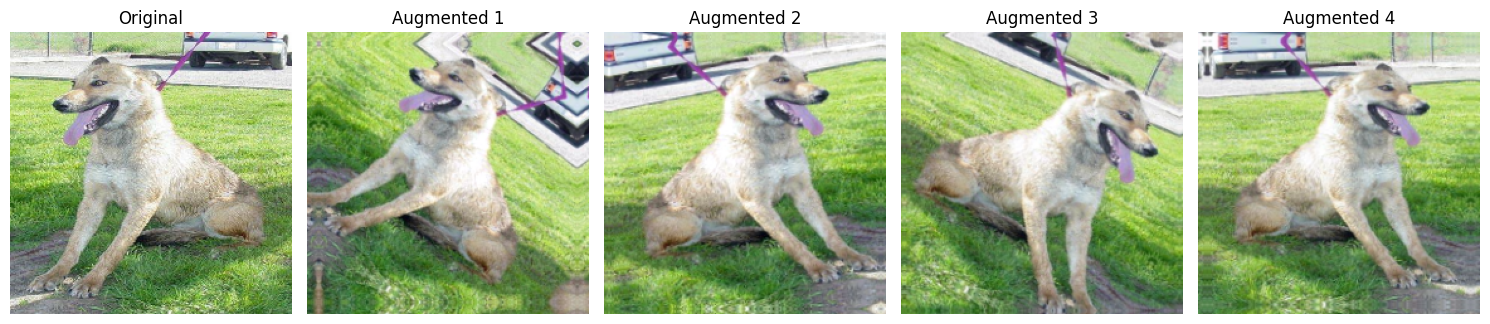

In [9]:
for images, labels in train_ds.take(1):
    original_image = images[0]
    break

plt.figure(figsize=(15, 6))

plt.subplot(1, 5, 1)
plt.imshow(original_image)
plt.title("Original")
plt.axis("off")

for i in range(4):
    augmented_image = data_augmentation(
        tf.expand_dims(original_image, 0),
        training=True
    )[0]

    plt.subplot(1, 5, i + 2)
    plt.imshow(augmented_image)
    plt.title(f"Augmented {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Question 3 : Custom CNN**

In [10]:
custom_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    # Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

custom_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,497 (42.61 MB)

 Trainable params: 11,169,793 (42.61 MB)

 Non-trainable params: 704 (2.75 KB)

### **Compile**

In [11]:
custom_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### **Early stopping**

In [12]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

### **Train**

In [13]:
custom_history = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 76s 137ms/step - accuracy: 0.6588 - loss: 0.6843 - val_accuracy: 0.6642 - val_loss: 0.6671
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 133ms/step - accuracy: 0.7343 - loss: 0.5304 - val_accuracy: 0.7768 - val_loss: 0.4799
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 65s 131ms/step - accuracy: 0.7713 - loss: 0.4695 - val_accuracy: 0.7736 - val_loss: 0.4769
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 65s 131ms/step - accuracy: 0.7964 - loss: 0.4389 - val_accuracy: 0.7806 - val_loss: 0.4889
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 132ms/step - accuracy: 0.8213 - loss: 0.4017 - val_accuracy: 0.7053 - val_loss: 0.7305
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 65s 130ms/step - accuracy: 0.8324 - loss: 0.3720 - val_accuracy: 0.7483 - val_loss: 0.5431


## **SAVE MODEL**

In [30]:
custom_model.save(
    '/content/drive/MyDrive/custom_cnn.keras'
)

### **Training Accuracy Plot**

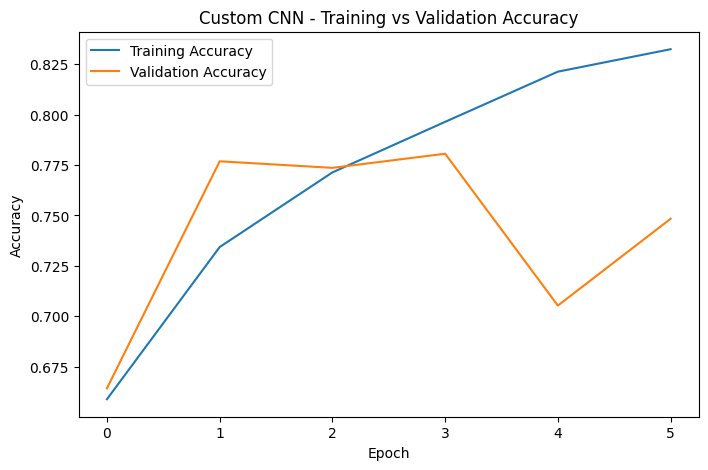

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    custom_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    custom_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom CNN - Training vs Validation Accuracy")
plt.legend()
plt.show()

### **Loss Plot**

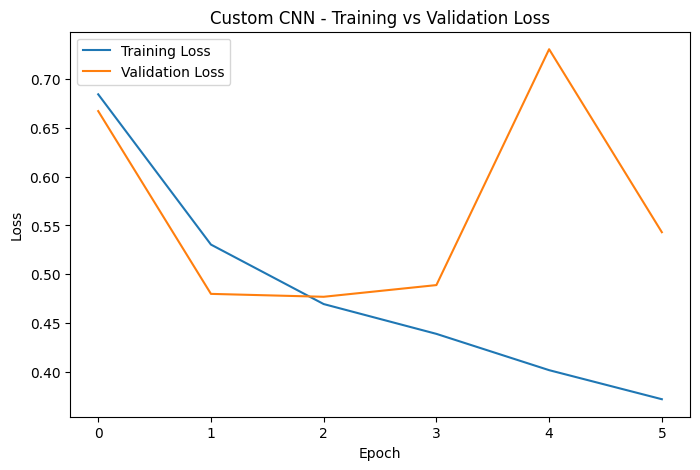

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    custom_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    custom_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN - Training vs Validation Loss")
plt.legend()
plt.show()

# **Question 4 : MobileNetV2 Feature Extraction**

In [18]:
mobilenet_base = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

mobilenet_base.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### **Model**

In [19]:
mobilenet_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(224, 224, 3)),

    # Convert [0,1] images to [-1,1] for MobileNetV2
    tf.keras.layers.Rescaling(2.0, offset=-1.0),

    mobilenet_base,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

mobilenet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### **Compile**

In [20]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### **Train**

In [21]:
early_stopping_mobilenet = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping_mobilenet]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 52s 80ms/step - accuracy: 0.9739 - loss: 0.0770 - val_accuracy: 0.9847 - val_loss: 0.0495
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.9867 - loss: 0.0376 - val_accuracy: 0.9850 - val_loss: 0.0430
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - accuracy: 0.9890 - loss: 0.0319 - val_accuracy: 0.9855 - val_loss: 0.0451
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - accuracy: 0.9888 - loss: 0.0313 - val_accuracy: 0.9845 - val_loss: 0.0483
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.9902 - loss: 0.0281 - val_accuracy: 0.9860 - val_loss: 0.0429
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - accuracy: 0.9905 - loss: 0.0271 - val_accuracy: 0.9857 - val_loss: 0.0433
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - accuracy: 0.9909 - loss: 0.0272 - val_accuracy: 0.9855 - val_loss: 0.0458
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.9922 - loss: 0.0230 - 

## **SAVE MODEL**

In [31]:
mobilenet_model.save(
    '/content/drive/MyDrive/mobilenet_model.keras'
)

### **Accuracy**

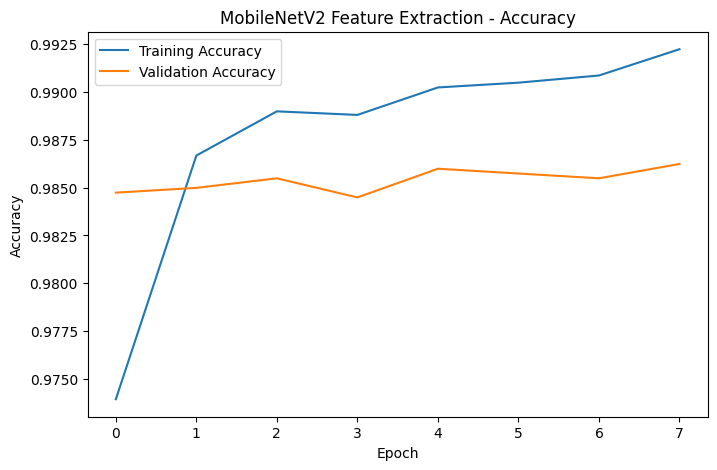

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    mobilenet_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    mobilenet_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Feature Extraction - Accuracy")
plt.legend()
plt.show()

### **Loss**

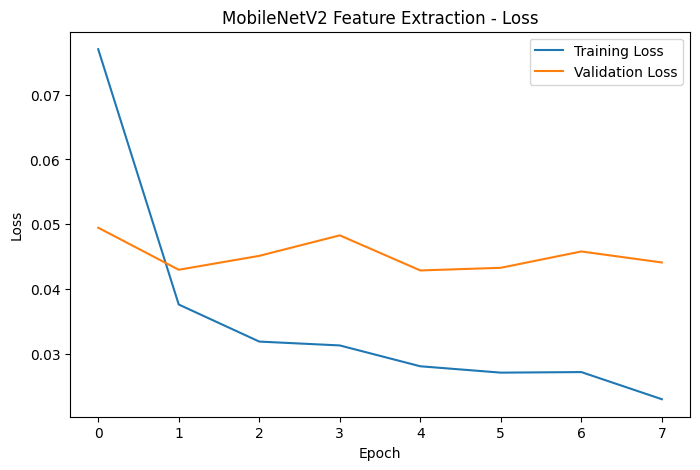

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    mobilenet_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    mobilenet_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Feature Extraction - Loss")
plt.legend()
plt.show()

# **Question 5 : Full Fine-Tuning with EfficientNetB0**

### **Model**

In [25]:
efficientnet_base = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

efficientnet_base.trainable = True

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [26]:
efficientnet_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(224, 224, 3)),

    # Dataset is normalized to [0,1], so convert back to [0,255]
    tf.keras.layers.Rescaling(255.0),

    efficientnet_base,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

efficientnet_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 4,008,829 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

### **Compile**

In [27]:
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### **Early stopping**

In [28]:
early_stopping_efficientnet = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

### **Train**

In [29]:
efficientnet_history = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping_efficientnet]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 244s 291ms/step - accuracy: 0.8764 - loss: 0.3501 - val_accuracy: 0.9742 - val_loss: 0.1271
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 119s 139ms/step - accuracy: 0.9684 - loss: 0.1159 - val_accuracy: 0.9825 - val_loss: 0.0647
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 136ms/step - accuracy: 0.9773 - loss: 0.0719 - val_accuracy: 0.9862 - val_loss: 0.0461
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 69s 138ms/step - accuracy: 0.9819 - loss: 0.0536 - val_accuracy: 0.9877 - val_loss: 0.0377
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 136ms/step - accuracy: 0.9872 - loss: 0.0411 - val_accuracy: 0.9890 - val_loss: 0.0328
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 137ms/step - accuracy: 0.9885 - loss: 0.0335 - val_accuracy: 0.9897 - val_loss: 0.0296
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 69s 137ms/step - accuracy: 0.9904 - loss: 0.0285 - val_accuracy: 0.9907 - val_loss: 0.0276
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 136ms/step - accuracy: 0.9922 - loss:

## **SAVE MODEL**

In [32]:
efficientnet_model.save(
    '/content/drive/MyDrive/efficientnet_model.keras'
)

### **Accuracy**

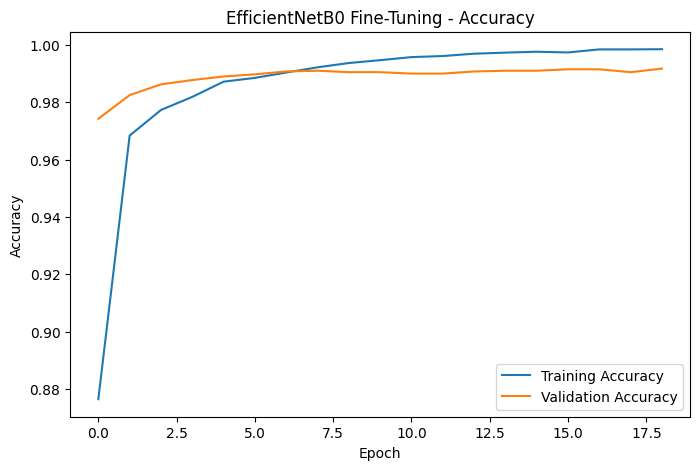

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(
    efficientnet_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    efficientnet_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetB0 Fine-Tuning - Accuracy")
plt.legend()
plt.show()

### **Loss**

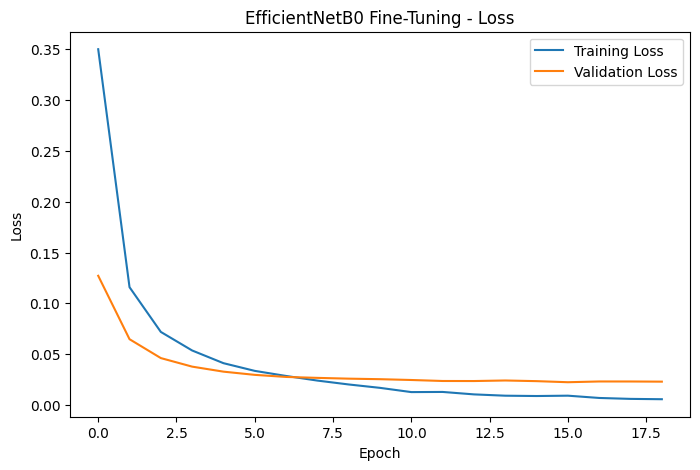

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    efficientnet_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    efficientnet_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 Fine-Tuning - Loss")
plt.legend()
plt.show()

# **Question 6 : Model Comparison**

In [35]:
def evaluate_model(model, dataset):
    loss, accuracy = model.evaluate(dataset, verbose=0)

    y_true = []
    y_prob = []

    for images, labels in dataset:
        probabilities = model.predict(images, verbose=0).ravel()

        y_true.extend(labels.numpy())
        y_prob.extend(probabilities)

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    y_pred = (y_prob >= 0.5).astype(int)

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return loss, accuracy, precision, recall, f1

### **Evaluate three models**

In [37]:
custom_test = evaluate_model(custom_model, test_ds)
mobilenet_test = evaluate_model(mobilenet_model, test_ds)
efficientnet_test = evaluate_model(efficientnet_model, test_ds)

print("Custom CNN:", custom_test)
print("MobileNetV2:", mobilenet_test)
print("EfficientNetB0:", efficientnet_test)

Custom CNN: (0.4770048260688782, 0.7757999897003174, 0.7788111605337646, 0.7704, 0.7745827468328976)
MobileNetV2: (0.033599358052015305, 0.989799976348877, 0.9884323893099322, 0.9912, 0.9898142600359496)
EfficientNetB0: (0.021159827709197998, 0.9929999709129333, 0.9928028788484606, 0.9932, 0.993001399720056)


In [38]:
def get_train_val_metrics(history):
    return {
        "Training Loss": history.history["loss"][-1],
        "Training Accuracy": history.history["accuracy"][-1],
        "Validation Loss": history.history["val_loss"][-1],
        "Validation Accuracy": history.history["val_accuracy"][-1]
    }


custom_metrics = get_train_val_metrics(custom_history)
mobilenet_metrics = get_train_val_metrics(mobilenet_history)
efficientnet_metrics = get_train_val_metrics(efficientnet_history)

In [39]:
comparison = pd.DataFrame({
    "Custom CNN": [
        custom_model.count_params(),
        custom_metrics["Training Loss"],
        custom_metrics["Training Accuracy"],
        custom_metrics["Validation Loss"],
        custom_metrics["Validation Accuracy"],
        custom_test[0],
        custom_test[1],
        custom_test[2],
        custom_test[3],
        custom_test[4]
    ],

    "MobileNetV2 Feature Extraction": [
        mobilenet_model.count_params(),
        mobilenet_metrics["Training Loss"],
        mobilenet_metrics["Training Accuracy"],
        mobilenet_metrics["Validation Loss"],
        mobilenet_metrics["Validation Accuracy"],
        mobilenet_test[0],
        mobilenet_test[1],
        mobilenet_test[2],
        mobilenet_test[3],
        mobilenet_test[4]
    ],

    "EfficientNetB0 Fine-Tuning": [
        efficientnet_model.count_params(),
        efficientnet_metrics["Training Loss"],
        efficientnet_metrics["Training Accuracy"],
        efficientnet_metrics["Validation Loss"],
        efficientnet_metrics["Validation Accuracy"],
        efficientnet_test[0],
        efficientnet_test[1],
        efficientnet_test[2],
        efficientnet_test[3],
        efficientnet_test[4]
    ]
}, index=[
    "Total Parameters",
    "Training Loss",
    "Training Accuracy",
    "Validation Loss",
    "Validation Accuracy",
    "Test Loss",
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1 Score"
])

comparison.round(4)

,Custom CNN,MobileNetV2 Feature Extraction,EfficientNetB0 Fine-Tuning
Total Parameters,1.117050e+07,2.259265e+06,4.050852e+06
Training Loss,3.720000e-01,2.300000e-02,5.700000e-03
Training Accuracy,8.324000e-01,9.922000e-01,9.985000e-01
Validation Loss,5.431000e-01,4.410000e-02,2.290000e-02
Validation Accuracy,7.483000e-01,9.862000e-01,9.917000e-01
Test Loss,4.770000e-01,3.360000e-02,2.120000e-02
Test Accuracy,7.758000e-01,9.898000e-01,9.930000e-01
Test Precision,7.788000e-01,9.884000e-01,9.928000e-01
Test Recall,7.704000e-01,9.912000e-01,9.932000e-01
Test F1 Score,7.746000e-01,9.898000e-01,9.930000e-01


## Model Comparison Discussion

The three models were evaluated using training loss, training accuracy,
validation loss, validation accuracy, test loss, test accuracy,
precision, recall, and F1-score.

### Best Performing Model

EfficientNetB0 with full fine-tuning performed the best overall.

It achieved a test accuracy of approximately **99.44%** and an F1-score
of approximately **99.44%**. It also achieved a very low test loss of
approximately **0.022**.

Therefore, EfficientNetB0 was the best-performing model among the three
models.

### Most Computationally Efficient Model

The Custom CNN has the highest number of parameters among the three
models in this experiment. The MobileNetV2 feature extraction model has
fewer parameters and only its classification head is trained, making it
more computationally efficient during training.

Feature extraction is generally faster because the pretrained backbone
is frozen and its weights do not need to be updated.

### Production Deployment

For production deployment, MobileNetV2 Feature Extraction could be a
good choice when computational resources, training time, or model size
are important.

However, if maximum classification performance is the main priority,
EfficientNetB0 Fine-Tuning would be preferred because it achieved the
highest test accuracy and F1-score in this experiment.

Overall, the choice depends on the trade-off between accuracy,
computational cost, inference speed, and available hardware.

# **Question 7 : Error Analysis**

In [40]:
def error_analysis(model, test_dataset, class_names):

    y_true = []
    y_pred = []
    y_prob = []
    images_list = []

    for images, labels in test_dataset:

        predictions = model.predict(images, verbose=0).ravel()

        predicted_labels = (predictions >= 0.5).astype(int)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted_labels)
        y_prob.extend(predictions)

        images_list.extend(images.numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)
    images_list = np.array(images_list)

    # Classification Report
    print("Classification Report")
    print("=" * 60)

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.title("Confusion Matrix")
    plt.show()

    # Incorrect predictions
    incorrect_indices = np.where(y_true != y_pred)[0]

    print("Number of incorrectly classified images:",
          len(incorrect_indices))

    # Show up to 9 incorrect images
    n = min(9, len(incorrect_indices))

    plt.figure(figsize=(12, 12))

    for i in range(n):

        index = incorrect_indices[i]

        plt.subplot(3, 3, i + 1)

        plt.imshow(images_list[index])

        actual_label = class_names[y_true[index]]
        predicted_label = class_names[y_pred[index]]

        # Convert probability to confidence
        if y_pred[index] == 1:
            confidence = y_prob[index]
        else:
            confidence = 1 - y_prob[index]

        plt.title(
            f"Actual: {actual_label}\n"
            f"Predicted: {predicted_label}\n"
            f"Confidence: {confidence:.2%}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

### **For EfficientNetB0**

Classification Report
              precision    recall  f1-score   support

        cats       0.99      0.99      0.99      2500
        dogs       0.99      0.99      0.99      2500

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



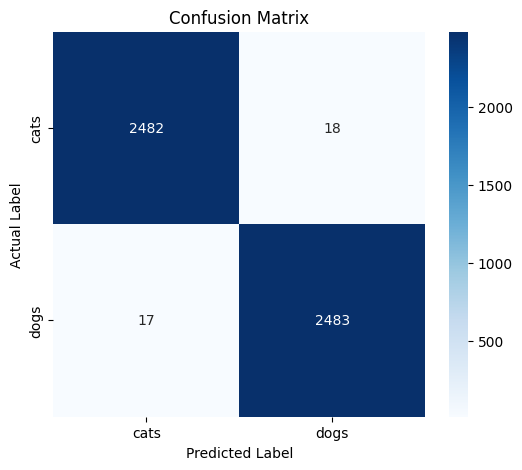

Number of incorrectly classified images: 35


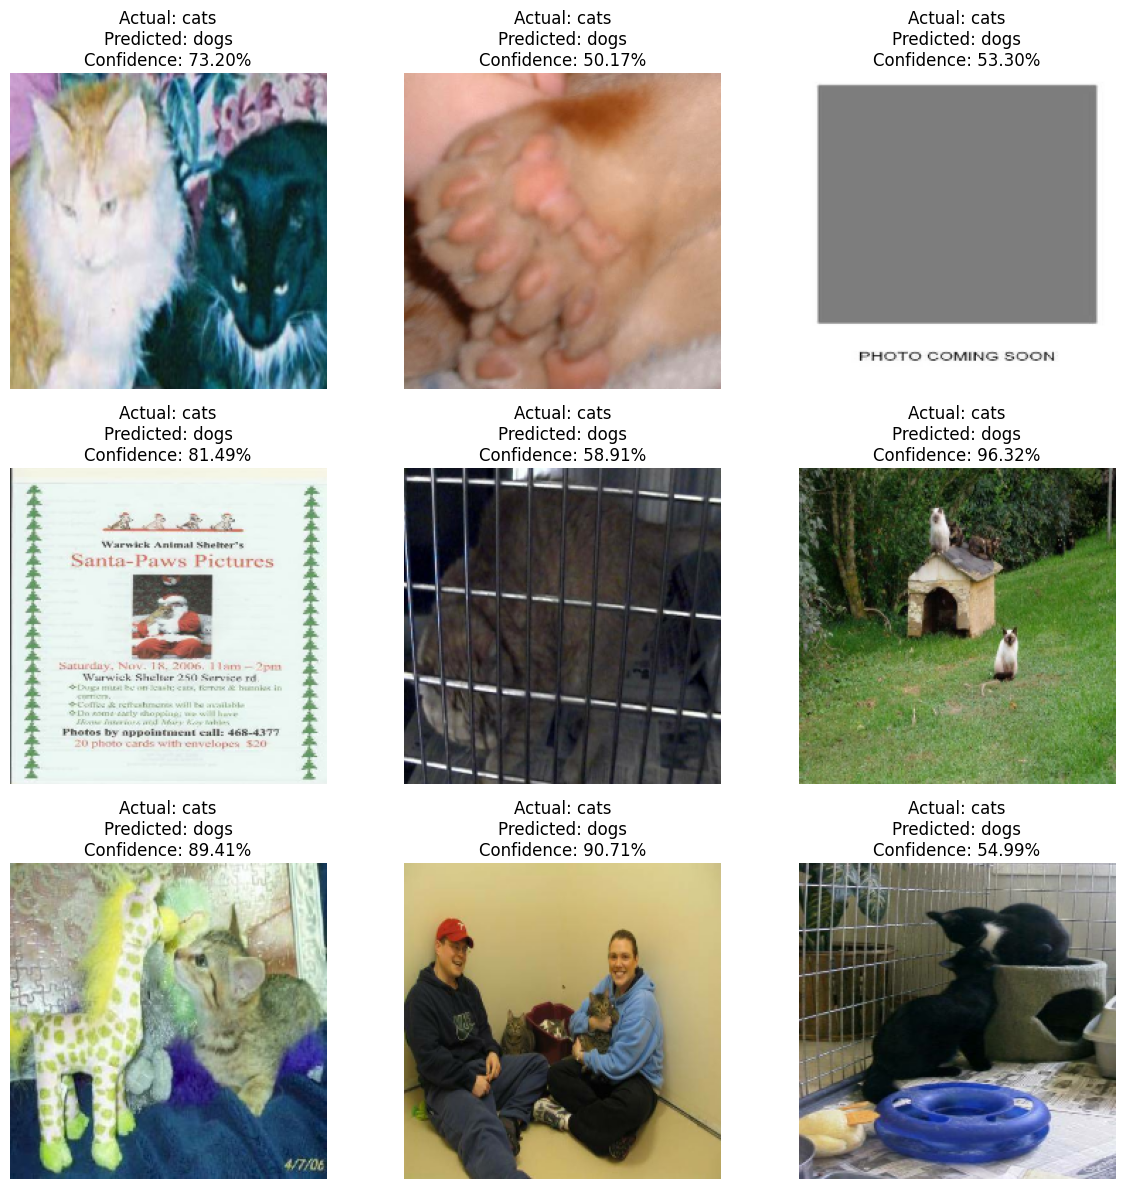

In [41]:
error_analysis(
    efficientnet_model,
    test_ds,
    class_names
)

### **For MobileNetV2**

Classification Report
              precision    recall  f1-score   support

        cats       0.99      0.99      0.99      2500
        dogs       0.99      0.99      0.99      2500

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



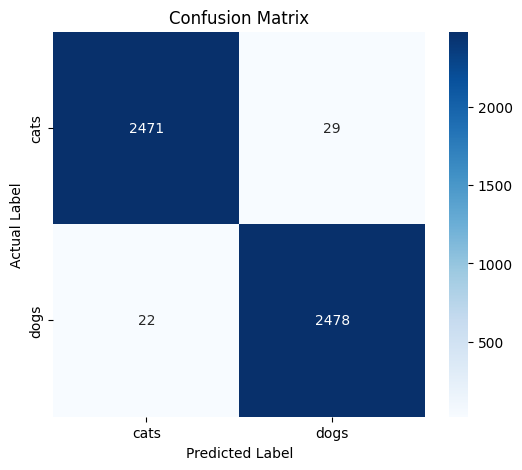

Number of incorrectly classified images: 51


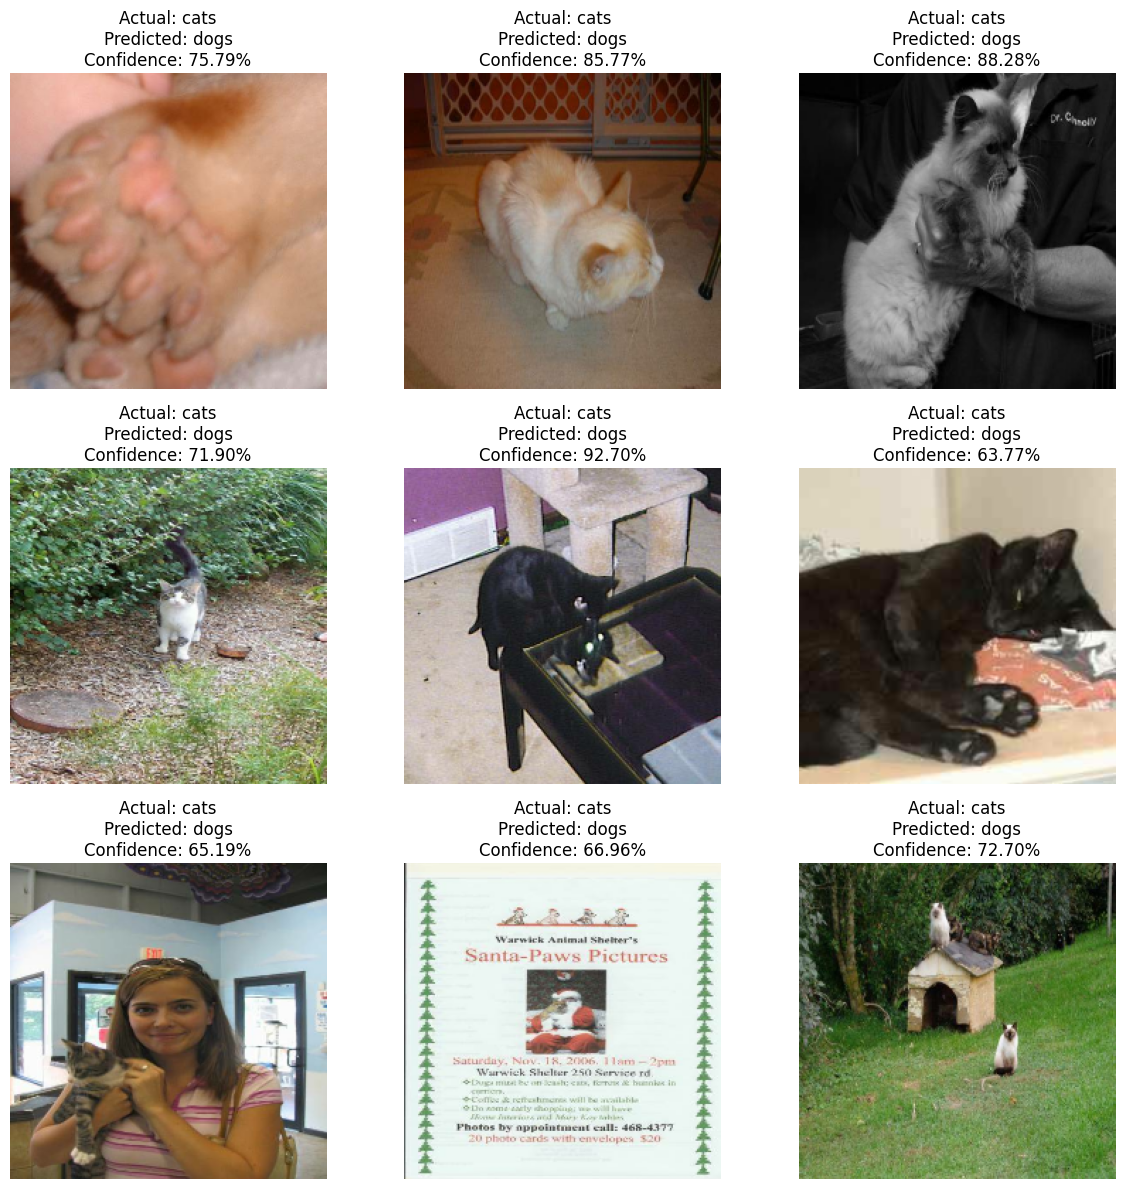

In [42]:
error_analysis(
    mobilenet_model,
    test_ds,
    class_names
)

### **For Custom CNN**

Classification Report
              precision    recall  f1-score   support

        cats       0.77      0.78      0.78      2500
        dogs       0.78      0.77      0.77      2500

    accuracy                           0.78      5000
   macro avg       0.78      0.78      0.78      5000
weighted avg       0.78      0.78      0.78      5000



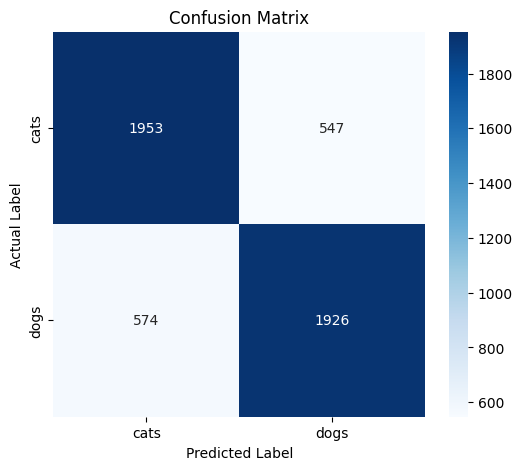

Number of incorrectly classified images: 1121


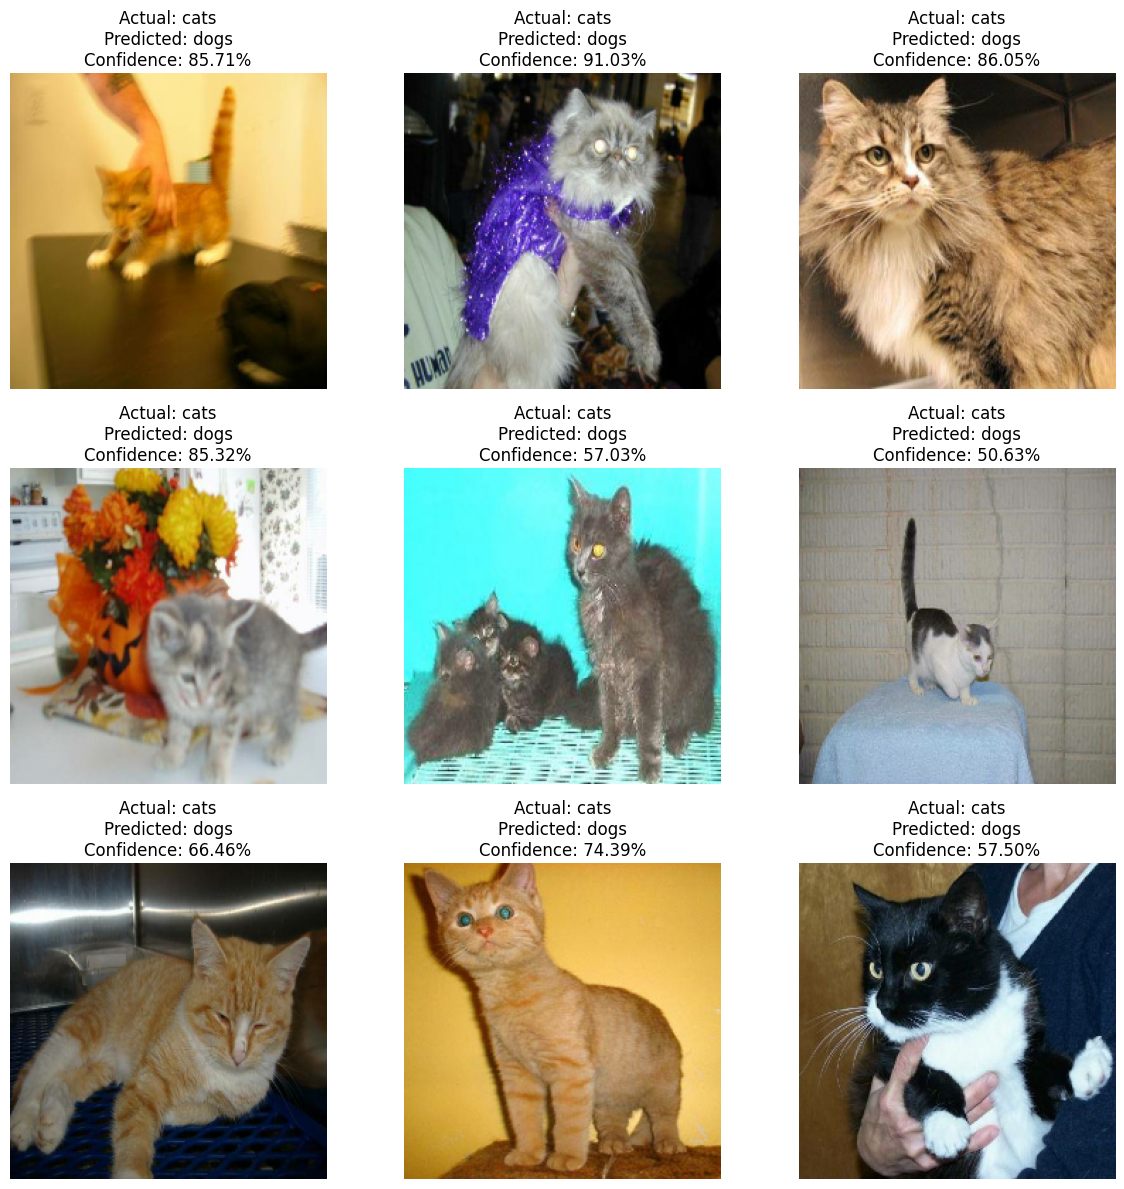

In [43]:
error_analysis(
    custom_model,
    test_ds,
    class_names
)